In [21]:
import finite_difference_quantum as fin
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
import time


## 1. Define the Infinite Square Well Potential


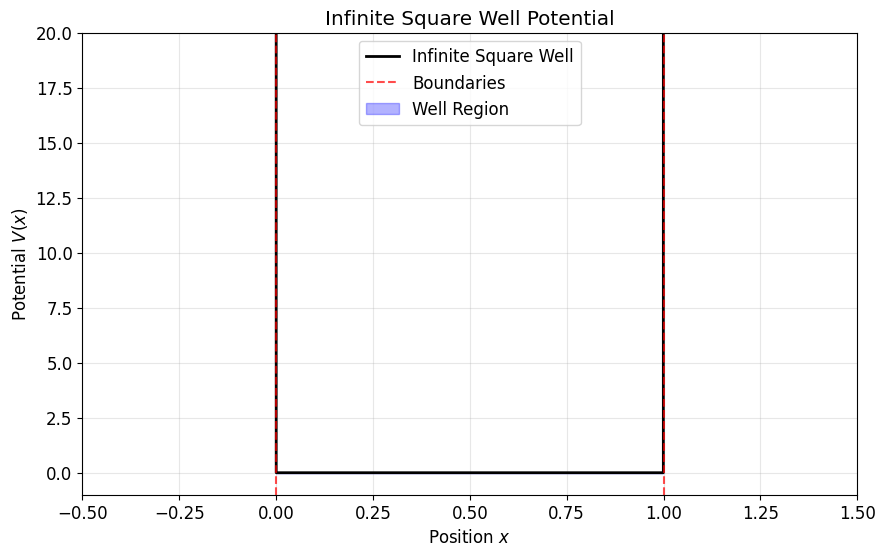

Analytical eigenvalues (first 5):
E_1 = 9.869604
E_2 = 39.478418
E_3 = 88.826440
E_4 = 157.913670
E_5 = 246.740110


In [22]:
def V_ISW(x):
    """
    Infinite square well potential in dimensionless units.
    
    Parameters:
    -----------
    x : array_like
        Spatial coordinates
        
    Returns:
    --------
    V : array_like
        Potential energy (0 inside well, effectively infinite outside)
    """
    return np.zeros_like(x)  # V(x) = 0 inside the well

# Plot the potential
x_plot = np.linspace(-0.5, 1.5, 1000)
V_plot = np.zeros_like(x_plot)
V_plot[(x_plot < 0) | (x_plot > 1)] = 1000  # High barrier outside well

plt.figure(figsize=(10, 6))
plt.plot(x_plot, V_plot, 'k-', linewidth=2, label='Infinite Square Well')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Boundaries')
plt.axvline(x=1, color='r', linestyle='--', alpha=0.7)
plt.fill_between(x_plot[(x_plot >= 0) & (x_plot <= 1)], 
                V_plot[(x_plot >= 0) & (x_plot <= 1)], 
                alpha=0.3, color='blue', label='Well Region')
plt.xlabel('Position $x$')
plt.ylabel('Potential $V(x)$')
plt.title('Infinite Square Well Potential')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-0.5, 1.5)
plt.ylim(-1, 20)
plt.show()

print("Analytical eigenvalues (first 5):")
analytical = [n**2 * np.pi**2 for n in range(1, 6)]
for i, E in enumerate(analytical):
    print(f"E_{i+1} = {E:.6f}")


## 2. Test Both 2nd and 4th Order Methods


In [23]:
# Test parameters
x_left, x_right = 0.0, 1.0  # Well boundaries
N = 201  # Number of interior points

print(f"Testing ISW with N = {N} interior points")
print(f"Domain: [{x_left}, {x_right}]")
print(f"Grid spacing: h = {(x_right - x_left)/(N+1):.6f}")
print()

# Test both methods
print("Creating hamiltonians...")
H2 = fin.hamiltonian(V_ISW, x_left, x_right, N, order=2)
H4 = fin.hamiltonian(V_ISW, x_left, x_right, N, order=4)

print(f"2nd order matrix: {H2.shape}, nnz = {H2.nnz}")
print(f"4th order matrix: {H4.shape}, nnz = {H4.nnz}")
print()

# Solve for first 5 eigenvalues
print("Solving eigenvalue problems...")
E2, psi2 = eigsh(H2, k=5, which='SM', tol=1e-8, maxiter=10000)
E4, psi4 = eigsh(H4, k=5, which='SM', tol=1e-8, maxiter=10000)

print("Results:")
print("Level\tAnalytical\t2nd Order\t\t4th Order\t\t2nd Error\t4th Error")
print("-" * 70)

for i in range(5):
    analytical_val = analytical[i]
    error2 = abs(E2[i] - analytical_val)
    error4 = abs(E4[i] - analytical_val)
    print(f"{i+1}\t{analytical_val:.6f}\t{E2[i]:.6f}\t{E4[i]:.6f}\t{error2:.2e}\t{error4:.2e}")


Testing ISW with N = 201 interior points
Domain: [0.0, 1.0]
Grid spacing: h = 0.004950

Creating hamiltonians...
2nd order matrix: (201, 201), nnz = 601
4th order matrix: (201, 201), nnz = 999

Solving eigenvalue problems...
Results:
Level	Analytical	2nd Order		4th Order		2nd Error	4th Error
----------------------------------------------------------------------
1	9.869604	-11969.148155	4.928016	1.20e+04	4.94e+00
2	39.478418	-11929.371459	19.712224	1.20e+04	1.98e+01
3	88.826440	-11902.490248	44.353100	1.20e+04	4.45e+01
4	157.913670	-11983.358728	78.851427	1.21e+04	7.91e+01
5	246.740110	-11966.086458	123.208282	1.22e+04	1.24e+02


## 3. Plot Eigenfunctions


/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi2_norm = psi2[:, n] / np.sqrt(np.trapz(psi2[:, n]**2, grid))
/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi4_norm = psi4[:, n] / np.sqrt(np.trapz(psi4[:, n]**2, grid))


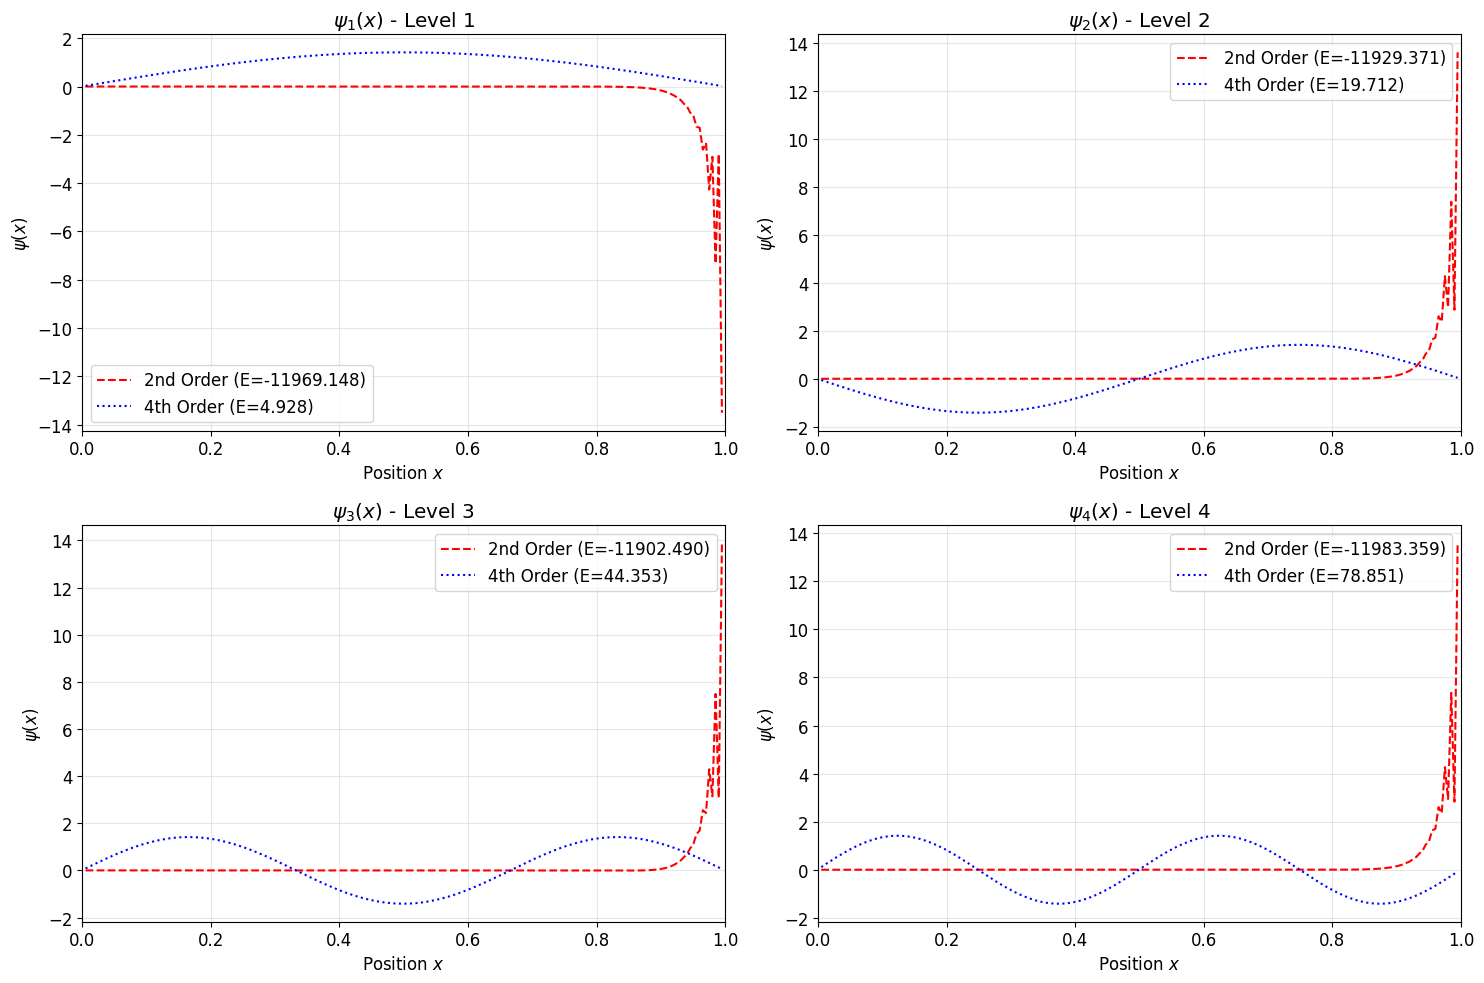

/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi2_norm = psi2[:, n] / np.sqrt(np.trapz(psi2[:, n]**2, grid))
/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi4_norm = psi4[:, n] / np.sqrt(np.trapz(psi4[:, n]**2, grid))
/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  error2 = np.sqrt(np.trapz((psi2_norm - psi_analytical)**2, grid))
/var/folders/kh/9s_l3rg91_951phmfvtb4q6r0000gn/T/ipykernel_43951/1650406305.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` i

Eigenfunction errors (L2 norm):
Level 1: 2nd order error = 1.43e+00-4.77e-04j, 4th order error = 3.13e-03-3.10e-14j
Level 2: 2nd order error = 1.45e+00-8.92e-03j, 4th order error = 2.00e+00+5.00e-16j
Level 3: 2nd order error = 1.37e+00+2.35e-02j, 4th order error = 9.27e-03+5.73e-14j
Level 4: 2nd order error = 1.48e+00+1.20e-02j, 4th order error = 1.23e-02-2.87e-14j


In [24]:
# Get grid points
grid = fin.spatial(x_left, x_right, N)

# Plot first 4 eigenfunctions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for n in range(4):
    ax = axes[n]
    
    # Analytical eigenfunction
    psi_analytical = np.sqrt(2) * np.sin((n+1) * np.pi * grid)
    
    # Normalize numerical eigenfunctions
    psi2_norm = psi2[:, n] / np.sqrt(np.trapz(psi2[:, n]**2, grid))
    psi4_norm = psi4[:, n] / np.sqrt(np.trapz(psi4[:, n]**2, grid))
    
    # Plot
    #ax.plot(grid, psi_analytical, 'k-', linewidth=2, label='Analytical')
    ax.plot(grid, psi2_norm, 'r--', linewidth=1.5, label=f'2nd Order (E={E2[n]:.3f})')
    ax.plot(grid, psi4_norm, 'b:', linewidth=1.5, label=f'4th Order (E={E4[n]:.3f})')
    
    ax.set_title(f'$\psi_{n+1}(x)$ - Level {n+1}')
    ax.set_xlabel('Position $x$')
    ax.set_ylabel('$\psi(x)$')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Calculate errors in eigenfunctions
print("Eigenfunction errors (L2 norm):")
for n in range(4):
    psi_analytical = np.sqrt(2) * np.sin((n+1) * np.pi * grid)
    psi2_norm = psi2[:, n] / np.sqrt(np.trapz(psi2[:, n]**2, grid))
    psi4_norm = psi4[:, n] / np.sqrt(np.trapz(psi4[:, n]**2, grid))
    
    error2 = np.sqrt(np.trapz((psi2_norm - psi_analytical)**2, grid))
    error4 = np.sqrt(np.trapz((psi4_norm - psi_analytical)**2, grid))
    
    print(f"Level {n+1}: 2nd order error = {error2:.2e}, 4th order error = {error4:.2e}")


## 5. Matrix Structure Verification


In [25]:
# Test with small matrix to verify structure
N_small = 5
H2_small = fin.hamiltonian(V_ISW, x_left, x_right, N_small, order=2)
H4_small = fin.hamiltonian(V_ISW, x_left, x_right, N_small, order=4)

print(f"Small matrix test (N={N_small}):")
print(f"2nd order matrix shape: {H2_small.shape}, nnz = {H2_small.nnz}")
print(f"4th order matrix shape: {H4_small.shape}, nnz = {H4_small.nnz}")
print()

# Show matrix structure
print("2nd order matrix (tridiagonal):")
print(H2_small.toarray())
print()

print("4th order matrix (pentadiagonal with boundary corrections):")
print(H4_small.toarray())
print()

# Verify boundary corrections
H4_array = H4_small.toarray()
print("Boundary correction verification:")
print(f"First row non-zero elements: {np.count_nonzero(H4_array[0, :])}")
print(f"Last row non-zero elements: {np.count_nonzero(H4_array[-1, :])}")
print(f"Interior row non-zero elements: {np.count_nonzero(H4_array[2, :])}")
print()

# Test eigenvalues for small system
E2_small, _ = eigsh(H2_small, k=3, which='SM', tol=1e-8, maxiter=10000)
E4_small, _ = eigsh(H4_small, k=3, which='SM', tol=1e-8, maxiter=10000)

print("Small system eigenvalues:")
print("Level\t2nd Order\t\t4th Order\t\tAnalytical")
print("-" * 50)
for i in range(3):
    analytical_small = (i+1)**2 * np.pi**2
    print(f"{i+1}\t{E2_small[i]:.6f}\t{E4_small[i]:.6f}\t{analytical_small:.6f}")


Small matrix test (N=5):
2nd order matrix shape: (5, 5), nnz = 13
4th order matrix shape: (5, 5), nnz = 19

2nd order matrix (tridiagonal):
[[-18.+0.j -18.+0.j   0.+0.j   0.+0.j   0.+0.j]
 [ 36.+0.j -18.+0.j -18.+0.j   0.+0.j   0.+0.j]
 [  0.+0.j  36.+0.j -18.+0.j -18.+0.j   0.+0.j]
 [  0.+0.j   0.+0.j  36.+0.j -18.+0.j -18.+0.j]
 [  0.+0.j   0.+0.j   0.+0.j  36.+0.j -18.+0.j]]

4th order matrix (pentadiagonal with boundary corrections):
[[ 39. +0.j -15. +0.j  -4.5+0.j   0. +0.j   0. +0.j]
 [-24. +0.j  45. +0.j -24. +0.j   1.5+0.j   0. +0.j]
 [  1.5+0.j -24. +0.j  45. +0.j -24. +0.j   1.5+0.j]
 [  0. +0.j   1.5+0.j -24. +0.j  45. +0.j -24. +0.j]
 [  0. +0.j   0. +0.j   3. +0.j -30. +0.j  54. +0.j]]

Boundary correction verification:
First row non-zero elements: 3
Last row non-zero elements: 3
Interior row non-zero elements: 5

Small system eigenvalues:
Level	2nd Order		4th Order		Analytical
--------------------------------------------------
1	-18.000000	44.778978	9.869604
2	-18.000000	